# Final Assignment
ECON 452

Students:
- Daniela Mendirichaga
- Chenny Yang
- Hanako Doerr

In [1]:
%pip install pyblp

Note: you may need to restart the kernel to use updated packages.


## **Model setup**
We study demand and supply for pizza products in Westwood.

Demand:

$$u_{ijt} = \beta_i^p \times p_{jt} + \beta^d \times deliverytime_{jt} + \beta^r \times rating_{jt} + \xi_{jt} + \epsilon_{ijt}$$

$$u_{i0t} = \alpha_i + \epsilon_{i0t}$$

$$\beta_i^p = \beta^p + \pi \times \frac{1}{Income_i}$$

$$\alpha_i \sim N(0, \sigma^2)$$

Supply:

$$mc_{jt} = \gamma_0 + \gamma_1 \times rating_{jt} + \gamma_3 \times hourlywages_{jt} + \gamma_4 \times deliverytime_{jt} + \omega_{jt}$$

Firms compete in a differentiated-products Bertrand pricing game.

# Question 1 Instrumental Variables

**Questions:**

1. **Explain why BLP instruments can be used to estimate demand parameters taking price endogeneity into account.**
2. **Explain verbally how `demand_instruments0` to `demand_instruments3` and `supply_instruments0` to `supply_instruments5` in `products_pizza.csv` are constructed.**
3. **Explain what shocks can be used as demand and supply instruments and how they relate to `demand_instruments4` and `supplyinstruments6`.**

**Answer 1:**

In the BLP demand model, price is endogenous because firms observe product characteristics (quality components) that the econometrician does not observe, and these unobserved quality components are captured by $\xi_{jt}$. If a product has higher unobserved quality, consumers value it more and firms can charge a higher price for it. As a result, price $p_{jt}$ is correlated with $\xi_{jt}$, so directly regressing demand on price would produce a biased estimate of the price effect.

BLP instruments address this problem by using instrumental variables; variables that change equilibrium prices but do not directly affect utility from product $j$. This is the exclusion restriction: the instrument can affect demand for product $j$ only indirectly through price, not by entering the utility of product $j$ itself.

In this setting, the characteristics of other products sold by the same firm and of rival firms' products can affect substitution patterns, competitive pressure, and markups, so they help explain the equilibrium price of product $j$. But these other-product characteristics are not characteristics of product $j$ itself, so they are excluded from the mean utility of product $j$. This gives the exogeneity condition needed for identification. After recovering mean utility $\delta_{jt}$, the demand parameters are then identified using GMM moment conditions of the form $E[\xi_{jt} Z_{jt}] = 0$.

**Answer 2:**

The BLP instruments are built by adding up characteristics of other products in the same market, always excluding product $j$ itself. There are two groups:

- non-rival goods: other pizzas sold by the same firm in the same market
- rival goods: pizzas sold by competing firms in the same market

So, the columns in the dataset can be interpreted as follows:

- demand_instruments0: sum of rating for the other pizzas sold by the same firm in the same market
- demand_instruments1: sum of rating for pizzas sold by rival firms in the same market
- demand_instruments2: sum of deliverytime for the other pizzas sold by the same firm in the same market
- demand_instruments3: sum of deliverytime for pizzas sold by rival firms in the same market

For the supply side, the same idea is used, but now the instruments are also built from variables that matter for costs:

- supply_instruments0: sum of hourlywages for the other pizzas sold by the same firm in the same market
- supply_instruments1: sum of hourlywages for pizzas sold by rival firms in the same market
- supply_instruments2: sum of rating for the other pizzas sold by the same firm in the same market
- supply_instruments3: sum of rating for pizzas sold by rival firms in the same market
- supply_instruments4: sum of deliverytime for the other pizzas sold by the same firm in the same market
- supply_instruments5: sum of deliverytime for pizzas sold by rival firms in the same market

The main idea is that characteristics of other pizzas affect the competitive environment around product $j$, so they can affect its equilibrium price. But because these sums are constructed from other products in the market rather than from product $j$ itself, they do not directly enter the utility or marginal cost of product $j$. That is why they can be used as excluded instruments.


**Answer 3:**

Demand instruments can come from cost shocks or cost shifters, such as wages or other input costs. These variables affect equilibrium prices through marginal cost, but they do not directly enter consumer utility. In this dataset, demand_instruments4 corresponds to hourlywages, so it is a demand instrument because it shifts prices through firms' costs while being excluded from utility.

Supply instruments can come from demand shocks or demand shifters that affect demand but do not directly affect firms' marginal costs. Here, income fits that idea better than the product characteristics. Inverse income changes consumer price sensitivity, so it shifts demand, but it does not appear in the marginal cost equation.

The assignment appears to contain a typo when it refers to supplyinstruments6. In products_pizza.csv, the supply-instrument columns run only from supply_instruments0 to supply_instruments5, so there is no separate supply_instruments6 variable to interpret. The natural reading is that the question is asking for the supply-side analogue of demand_instruments4: a demand shifter that affects firms' pricing incentives but does not enter marginal cost directly. In this model, inverse income is the clearest example of that kind of supply instrument.


# Question 2- model

## Load Packages and Data

In [2]:
import pyblp
import numpy as np
import pandas as pd

# import os module
import os
import matplotlib.pyplot as plt

pyblp.options.digits = 2
pyblp.options.verbose = False
pyblp.__version__

'1.1.2'

In [3]:
product_data = pd.read_csv("products_pizza.csv")
product_data.head()

,v1,market_ids,firm_ids,shares,demand_instruments0,demand_instruments1,demand_instruments2,demand_instruments3,demand_instruments4,supply_instruments0,supply_instruments1,supply_instruments2,supply_instruments3,supply_instruments4,supply_instruments5,prices,deliverytime,rating,hourlywages
0,0,0,0,0.006038,1.873110,9.154572,1.199421,10.333022,0.783960,2.284171,7.219228,1.873110,9.154572,1.199421,10.333022,4.586001,NaN,2.462066,0.783960
1,1,0,0,0.008047,2.242486,9.154572,1.271857,10.333022,0.458989,2.609143,7.219228,2.242486,9.154572,1.271857,10.333022,4.171702,0.643810,1.701694,0.458989
2,2,0,0,0.004980,2.174373,9.154572,1.883209,10.333022,0.618113,2.450018,7.219228,2.174373,9.154572,1.883209,10.333022,4.966030,0.032459,1.821641,0.618113
3,3,0,0,0.006846,2.471596,9.154572,1.901145,10.333022,0.635290,2.432842,7.219228,2.471596,9.154572,1.901145,10.333022,4.120471,0.014522,1.353257,0.635290
4,4,0,0,0.011540,2.334877,9.154572,1.407037,10.333022,0.571779,2.496352,7.219228,2.334877,9.154572,1.407037,10.333022,3.267534,0.508631,1.551517,0.571779


In [4]:
agent_data = pd.read_csv("agents_pizza.csv")
agent_data.head()

,v1,market_ids,nodes0,nodes1,weights,invincome
0,0,0,0.052184,-0.127630,0.001,0.693219
1,1,0,-2.037323,-1.195798,0.001,0.177587
2,2,0,0.741513,0.443902,0.001,0.200069
3,3,0,-0.610369,-0.417627,0.001,0.664243
4,4,0,0.374030,-2.591600,0.001,0.307349


## Clean data

In [5]:
product_data.isna().sum()

v1                       0
market_ids               0
firm_ids                 0
shares                   0
demand_instruments0      0
demand_instruments1      0
demand_instruments2      0
demand_instruments3      0
demand_instruments4      0
supply_instruments0      0
supply_instruments1      0
supply_instruments2      0
supply_instruments3      0
supply_instruments4      0
supply_instruments5      0
prices                   0
deliverytime           100
rating                   0
hourlywages              0
dtype: int64

In [6]:
product_data.describe()

,v1,market_ids,firm_ids,shares,demand_instruments0,demand_instruments1,demand_instruments2,demand_instruments3,demand_instruments4,supply_instruments0,supply_instruments1,supply_instruments2,supply_instruments3,supply_instruments4,supply_instruments5,prices,deliverytime,rating,hourlywages
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,400.000000,500.000000,500.000000
mean,249.500000,9.500000,2.400000,0.015191,1.624923,10.604966,1.705427,11.047504,0.486413,1.559444,10.114476,1.624923,10.604966,1.705427,11.047504,3.499337,0.535267,1.733714,0.486413
std,144.481833,5.772056,1.745306,0.011910,0.525439,1.609503,0.557857,1.248256,0.291678,0.553768,1.421121,0.525439,1.609503,0.557857,1.248256,1.269839,0.284407,0.492360,0.291678
min,0.000000,0.000000,0.000000,0.001773,0.261239,6.044249,0.330828,8.423076,0.000490,0.303668,7.219228,0.261239,6.044249,0.330828,8.423076,0.781472,0.001092,1.001305,0.000490
25%,124.750000,4.750000,1.000000,0.006824,1.266643,9.588965,1.308629,9.999157,0.233056,1.149368,8.952020,1.266643,9.588965,1.308629,9.999157,2.568873,0.281786,1.301279,0.233056
50%,249.500000,9.500000,2.000000,0.011253,1.640795,10.888952,1.678429,11.150147,0.476540,1.548895,9.969613,1.640795,10.888952,1.678429,11.150147,3.409020,0.549806,1.645082,0.476540
75%,374.250000,14.250000,4.000000,0.020239,2.002215,11.780278,2.042425,11.809238,0.744358,1.972394,11.100945,2.002215,11.780278,2.042425,11.809238,4.347939,0.772699,2.162719,0.744358
max,499.000000,19.000000,5.000000,0.068168,2.807821,13.456462,3.404543,14.395259,0.999702,3.287601,14.430416,2.807821,13.456462,3.404543,14.395259,6.883919,0.997814,2.711978,0.999702


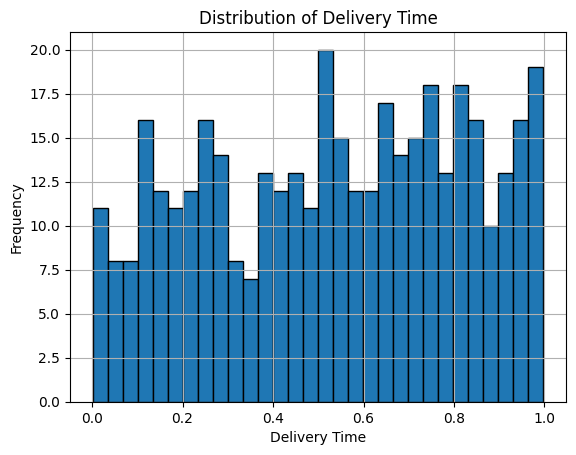

In [7]:
# check distribution of delivery time to decide on imputation
product_data['deliverytime'].dropna().hist(bins=30, edgecolor='black')
plt.xlabel('Delivery Time')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery Time')
plt.show()

In [8]:
# # mean impute null values in delivery time
# product_data['deliverytime'].fillna(product_data['deliverytime'].mean(), inplace=True)

In [9]:
# Mean imputation by product / firm pair
# Step 2: Implement group-based mean imputation
# Calculate the mean deliverytime for each (market_ids, firm_ids) group
group_means = product_data.groupby(['market_ids', 'firm_ids'])['deliverytime'].transform('mean')

# Create a copy to impute missing values
product_data_imputed = product_data.copy()

# Impute missing values with group means
missing_mask = product_data_imputed['deliverytime'].isna()
product_data_imputed.loc[missing_mask, 'deliverytime'] = group_means[missing_mask]

# override original
product_data = product_data_imputed


In [10]:
agent_data.isna().sum()

v1            0
market_ids    0
nodes0        0
nodes1        0
weights       0
invincome     0
dtype: int64

## Set up the problem

In [11]:
# set up the problem
product_formulations = (
   pyblp.Formulation('0 + prices + deliverytime + rating'),
   pyblp.Formulation('1 + prices'),
   pyblp.Formulation('1 + rating + hourlywages + deliverytime')
)
product_formulations

(prices + deliverytime + rating,
 1 + prices,
 1 + rating + hourlywages + deliverytime)

In [12]:
# set up the problem
agent_formulation = pyblp.Formulation('0 + invincome')
agent_formulation

invincome

## Initialize the problem

In [13]:
# initialize the problem
problem = pyblp.Problem(product_formulations, product_data, agent_formulation, agent_data)
problem

Dimensions:
 T    N    F     I     K1    K2    K3    D    MD    MS 
---  ---  ---  -----  ----  ----  ----  ---  ----  ----
20   500   6   20000   3     2     4     1    7     10 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         

## Solving the problem

In [14]:
# set starting values
initial_sigma = np.diag([1, 0])
initial_pi = np.c_[[0, -1]]
initial_beta=np.c_[[-1, -1, 1]]
initial_gamma=np.c_[[-1, 1, 1, -1]]

In [15]:
results = problem.solve(
    initial_sigma,
    initial_pi,
    beta=initial_beta,
    gamma=initial_gamma,
    costs_bounds=(0.001, None),
    #W_type='clustered',
    #se_type='clustered',
    initial_update=True,
    optimization=pyblp.Optimization('l-bfgs-b', {'gtol': 1e-5})
)
results

Problem Results Summary:
GMM   Objective    Projected    Reduced Hessian  Reduced Hessian  Clipped  Clipped  Weighting Matrix  Covariance Matrix
Step    Value    Gradient Norm  Min Eigenvalue   Max Eigenvalue   Shares    Costs   Condition Number  Condition Number 
----  ---------  -------------  ---------------  ---------------  -------  -------  ----------------  -----------------
 2    +1.8E+01     +7.0E-03        +5.5E+00         +2.7E+05         0        0         +1.2E+05          +5.8E+05     

Cumulative Statistics:
Computation  Optimizer  Optimization   Objective   Fixed Point  Contraction
   Time      Converged   Iterations   Evaluations  Iterations   Evaluations
-----------  ---------  ------------  -----------  -----------  -----------
 00:00:38       Yes         298           352         50650       157300   

Nonlinear Coefficient Estimates (Robust SEs in Parentheses):
Sigma:      1        prices   |   Pi:    invincome 
------  ----------  --------  |  ------  ----------
 

### Interpretation

* linear demand $(\beta)$:
The linear demand estimates imply that delivery time has a coefficient of about -0.85 and rating has a coefficient of about 0.92. So a one-unit increase in delivery time lowers mean utility by about 0.85, while a one-unit increase in rating raises mean utility by about 0.92. This is consistent with the idea that consumers prefer faster delivery and better quality.

* marginal cost $(\gamma)$
The marginal cost estimates imply that the constant is about 0.69, the coefficient on rating is about 0.47, the coefficient on hourly wages is about 1.3, and the coefficient on delivery time is about -0.69. So higher ratings and higher wages are associated with higher marginal costs, while longer delivery times are associated with lower marginal cost. The wage effect is intuitive because labor is a direct input into production and delivery. The negative coefficient on delivery time suggests that slower delivery may reflect lower-cost production or staffing choices.

* nonlinear estimates $(\sigma)$ and $(\pi)$
The nonlinear part allows heterogeneity in the utility of the outside good and in price sensitivity through inverse income. The estimated demographic interaction $\pi$ is about -4.2, which means inverse income has a strong effect on price sensitivity: consumers with lower inverse income are less price sensitive, while consumers with higher inverse income are more price sensitive.

* starting values
We chose starting values to match the signs we expected economically and to keep the optimization numerically stable. We started $\sigma$ at `diag([1, 0])` because the outside-good random coefficient should have some dispersion, while the price coefficient does not have its own random term in our specification. We set $\pi = [0, -1]$ so that the demographic interaction starts from the idea that higher inverse income makes consumers more price sensitive. We initialized $\beta = [-1, -1, 1]$ so price and delivery time begin with negative effects on utility and rating begins with a positive effect. We initialized $\gamma = [-1, 1, 1, -1]$ so the cost function starts from the idea that ratings and wages raise cost, while longer delivery times are associated with lower marginal cost. These are not imposed restrictions on the final estimates; they are just reasonable starting points that help the solver converge to an economically sensible solution.


# Question 3 - Elasticities and Diversion ratios

In [16]:
elasticities = results.compute_elasticities()
diversions = results.compute_diversion_ratios()

### Elasticities

In [17]:
# look at market ids
product_data['market_ids'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [18]:
product_data.groupby('market_ids')['shares'].sum()

market_ids
0     0.424036
1     0.349357
2     0.387672
3     0.388787
4     0.389075
5     0.390935
6     0.363258
7     0.409922
8     0.364449
9     0.388503
10    0.366352
11    0.376966
12    0.329694
13    0.413926
14    0.327866
15    0.394372
16    0.363029
17    0.415907
18    0.388556
19    0.362657
Name: shares, dtype: float64

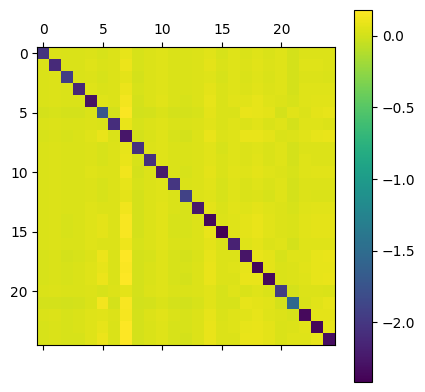

In [19]:
# Plot elasticities for market 0
single_market = product_data['market_ids'] == 0
plt.colorbar(plt.matshow(elasticities[single_market]));

### Interpretation

The own-price elasticities are on the diagonal, and they look to be around -1.5 to -2.0 in this market. That means demand is elastic: a 1 percent increase in price leads to a more than 1 percent drop in quantity demanded.

The cross-price elasticities are the off-diagonal entries. They are small and close to 0, which suggests that when one pizza place raises its price, demand for the other pizzas changes only a little.

So overall, consumers seem quite responsive to a product's own price, but substitution across specific pizza options is fairly limited in this market.


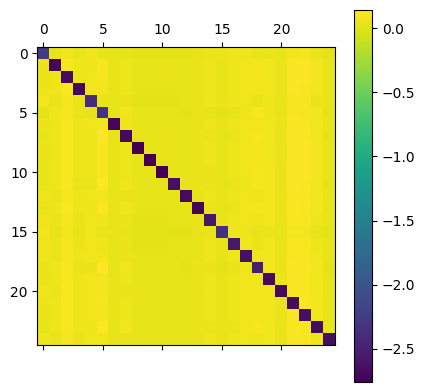

In [20]:
# Plot elasticities for market 14
single_market2 = product_data['market_ids'] == 14
plt.colorbar(plt.matshow(elasticities[single_market2]));

### Interpretation

The first market I plotted was market 0. I also plotted market 14, which has a relatively low inside share. In market 14 the own-price elasticities are larger in absolute value, while the cross-price elasticities remain close to 0. This is consistent with the logit demand structure, where products with smaller shares tend to have more elastic demand because consumers can more easily substitute away from them. The cross-price elasticities being near 0 suggests that when a product raises its price, much of the substitution goes to the outside option rather than to a specific competing pizza.


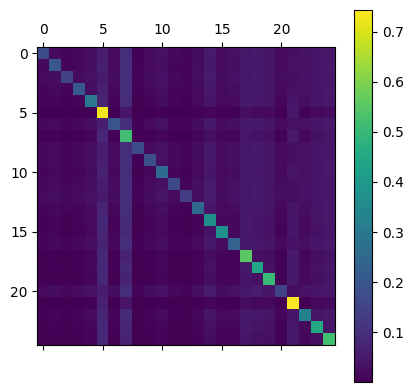

In [21]:
# Plotting diversion ratios
plt.colorbar(plt.matshow(diversions[single_market]));

### Interpretation

The off-diagonal entries are diversion to other pizza places, and most of them look to be around 10 to 20 percent. So if one pizza place raises its price, some consumers switch to competing pizza options, but not a huge share.

The diagonal entries capture diversion to the outside good, and they are much larger, around 30 to 70 percent. That means a lot of consumers respond to a price increase by leaving the pizza market rather than switching to a different pizza place.

This suggests that pizza places do compete with one another, but a large part of substitution is still between buying pizza and choosing the outside option.


# Question 4 - Marginal Costs, Markups, HHI, Consumer Surplus, and Profits


In [22]:
# Question 4: model-based objects from the estimated equilibrium.

# Compute marginal costs, markups, and HHI from the estimated pyblp results.
q4_costs = results.compute_costs().flatten()
q4_markups = results.compute_markups(costs=q4_costs).flatten()
q4_hhi = results.compute_hhi().flatten()

# Scale profits and consumer surplus using the assignment's market size and 6 slices per pizza.
q4_market_population = 100_000
q4_slices_per_pizza = 6
q4_profits = results.compute_profits(costs=q4_costs).flatten() * q4_market_population * q4_slices_per_pizza
q4_cs = results.compute_consumer_surpluses().flatten() * q4_market_population

# Build a product-level table with baseline outcomes and the model-implied cost and profit objects.
q4_product_table = product_data[['v1', 'market_ids', 'firm_ids', 'prices', 'shares']].copy()
q4_product_table['marginal_cost'] = q4_costs
q4_product_table['markup'] = q4_markups
q4_product_table['profit'] = q4_profits

# Build market-level summaries for concentration and consumer surplus, then compute descriptive statistics.
q4_market_table = pd.DataFrame({
    'market_ids': pd.Index(sorted(product_data['market_ids'].unique())),
    'hhi': q4_hhi,
    'consumer_surplus': q4_cs,
})

q4_mc_summary = pd.Series(q4_costs).describe().to_frame('marginal_cost')
q4_markup_summary = pd.Series(q4_markups).describe().to_frame('markup')
q4_hhi_summary = pd.Series(q4_hhi).describe().to_frame('hhi')
q4_profit_summary = pd.Series(q4_profits).describe().to_frame('profit')
q4_cs_summary = pd.Series(q4_cs).describe().to_frame('consumer_surplus')

,v1,market_ids,firm_ids,prices,shares,marginal_cost,markup,profit
0,0,0,0,4.586001,0.006038,2.138679,0.533651,8865.580362
1,1,0,0,4.171702,0.008047,2.037529,0.511583,10304.277626
2,2,0,0,4.966030,0.004980,2.219800,0.553003,8206.078292
3,3,0,0,4.120471,0.006846,2.023821,0.508837,8611.705133
4,4,0,0,3.267534,0.011540,1.744537,0.466100,10544.778646
5,5,0,1,0.968238,0.060462,0.353261,0.635151,22309.651073
6,6,0,1,4.306469,0.007761,2.078307,0.517399,10376.183747
7,7,0,1,1.987181,0.050265,1.034755,0.479285,28724.361071
8,8,0,1,4.546549,0.003045,2.146853,0.527806,4384.201615
9,9,0,2,4.438455,0.007630,2.137193,0.518483,10535.440629


,market_ids,hhi,consumer_surplus
0,0,2040.019633,321607.791000
1,1,2266.968603,440269.937928
2,2,1910.292655,326029.759978
3,3,1705.866064,396284.890999
4,4,1810.765776,433376.015985
5,5,1713.712189,501164.782410
6,6,1768.664444,346086.532626
7,7,1824.744946,422762.057109
8,8,1914.131328,363761.890344
9,9,1727.717476,338896.526215


,marginal_cost
count,500.000000
mean,1.823218
std,0.578773
min,0.230516
25%,1.429346
50%,1.845768
75%,2.246162
max,3.166607


,markup
count,500.000000
mean,0.472042
std,0.045229
min,0.377983
25%,0.441525
50%,0.462936
75%,0.493525
max,0.705023


,hhi
count,20.000000
mean,1823.348699
std,140.186253
min,1677.246362
25%,1712.707151
50%,1795.216258
75%,1886.604176
max,2266.968603


,profit
count,500.000000
mean,12007.527552
std,5547.711984
min,1948.560693
25%,7923.397612
50%,11020.381518
75%,14907.541818
max,32211.083933


,consumer_surplus
count,20.000000
mean,399022.210219
std,58108.069800
min,321607.791000
25%,352899.279716
50%,392503.854908
75%,432507.001063
max,524058.019580


Markets with HHI >= 2500: 0 out of 20


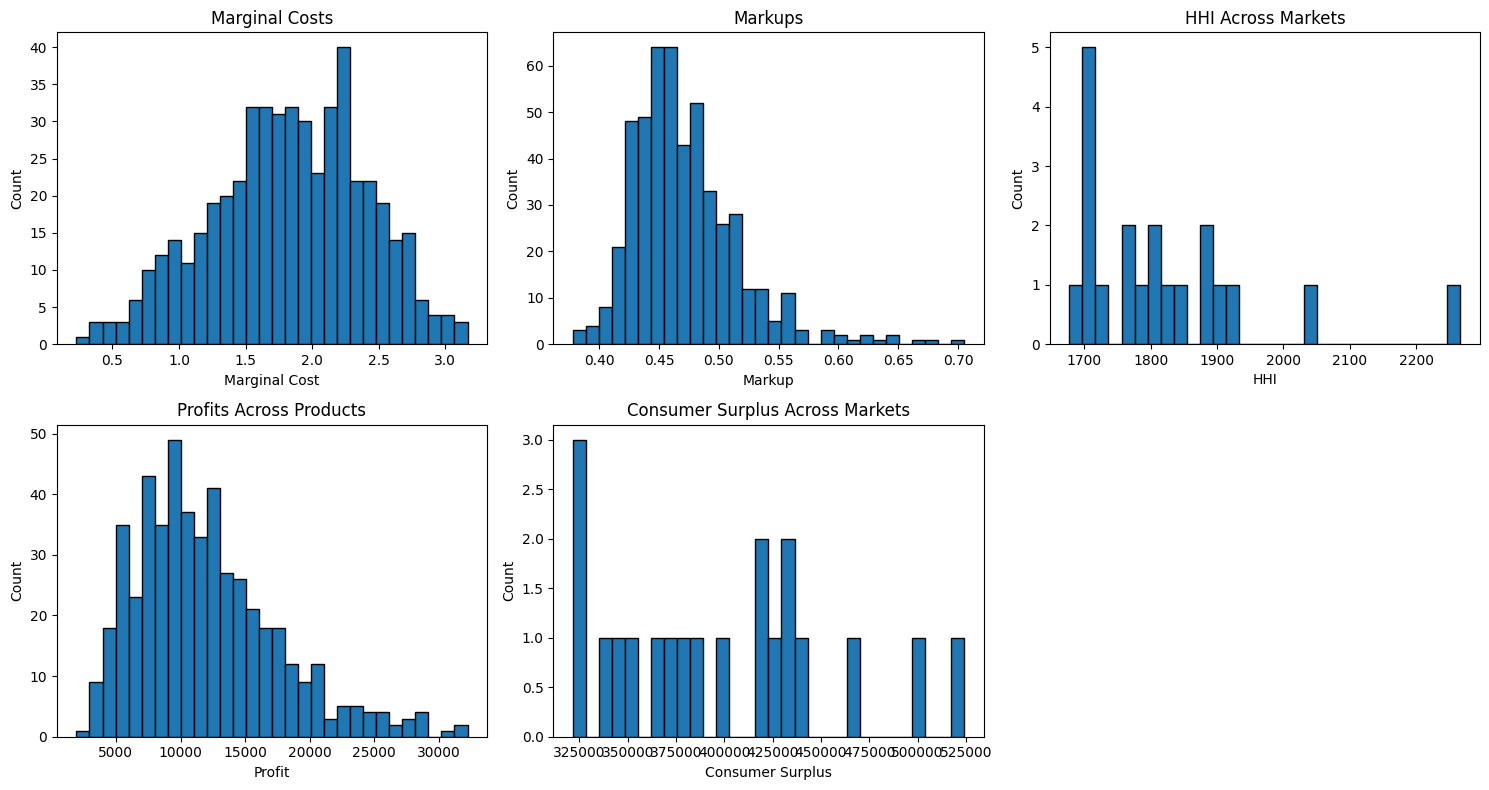

In [23]:
display(q4_product_table.head(10))
display(q4_market_table.head(10))
display(q4_mc_summary)
display(q4_markup_summary)
display(q4_hhi_summary)
display(q4_profit_summary)
display(q4_cs_summary)
print(f"Markets with HHI >= 2500: {(q4_market_table['hhi'] >= 2500).sum()} out of {len(q4_market_table)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plot_data = [
    (q4_costs, 'Marginal Costs', 'Marginal Cost'),
    (q4_markups, 'Markups', 'Markup'),
    (q4_hhi, 'HHI Across Markets', 'HHI'),
    (q4_profits, 'Profits Across Products', 'Profit'),
    (q4_cs, 'Consumer Surplus Across Markets', 'Consumer Surplus'),
]
for ax, (data, title, xlabel) in zip(axes, plot_data):
    ax.hist(data, bins=30, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Interpretation

The average marginal cost is about 1.82 dollars per slice. Since average prices in the sample are around 3 to 5 dollars per slice, this suggests that marginal cost is a substantial share of price, but still leaves room for positive markups.

The average markup is about 0.47, so on average firms keep roughly 47 percent of price above marginal cost. This is economically large but still plausible in a differentiated-products market. Using the Lerner-index logic, a markup of this size is broadly consistent with the elasticities we found above: with average own-price elasticities around 1.5 to 2 in absolute value, firms can sustain meaningful but not extreme price-cost margins.

The average HHI is about 1823, and no market has HHI above 2500. So none of the markets would be classified as highly concentrated under the usual threshold.

Assuming a full pizza has 6 slices and there are 100,000 consumers in each market, the average profit is about 12,008 dollars per product.

Under the same scaling, the average consumer surplus is about 399,022 dollars per market.


# Question 5 - Merger Analysis


In [24]:
# Question 5: merger counterfactual using Week 10 methods.

# Reassign ownership so firms 0, 1, 2, and 3 are treated as one merged firm after the acquisition.
q5_merger_ids = product_data['firm_ids'].replace({0: 1, 2: 1, 3: 1}).to_numpy()

# Use 100,000 consumers in total across markets for the merger consumer-surplus calculation.
q5_market_population = 100_000 / product_data['market_ids'].nunique()

# Solve for the post-merger equilibrium and compute the new prices, shares, concentration, markups, profits, and consumer surplus.
q5_changed_prices = results.compute_prices(firm_ids=q5_merger_ids, costs=q4_costs).flatten()
q5_changed_shares = results.compute_shares(q5_changed_prices).flatten()
q5_changed_hhi = results.compute_hhi(firm_ids=q5_merger_ids, shares=q5_changed_shares).flatten()
q5_changed_markups = results.compute_markups(q5_changed_prices, q4_costs).flatten()
q5_changed_profits = results.compute_profits(q5_changed_prices, q5_changed_shares, q4_costs).flatten() * q4_market_population * q4_slices_per_pizza
q5_changed_cs = results.compute_consumer_surpluses(q5_changed_prices).flatten() * q5_market_population

# Build a product-level table that compares baseline and post-merger outcomes for prices, shares, markups, and profits.
q5_product_table = product_data[['v1', 'market_ids', 'firm_ids', 'prices', 'shares']].copy()
q5_product_table['post_merger_firm_id'] = q5_merger_ids
q5_product_table['new_price'] = q5_changed_prices
q5_product_table['new_share'] = q5_changed_shares
q5_product_table['delta_price'] = q5_product_table['new_price'] - q5_product_table['prices']
q5_product_table['delta_share'] = q5_product_table['new_share'] - q5_product_table['shares']
q5_product_table['baseline_markup'] = q4_markups
q5_product_table['new_markup'] = q5_changed_markups
q5_product_table['delta_markup'] = q5_product_table['new_markup'] - q5_product_table['baseline_markup']
q5_product_table['baseline_profit'] = q4_profits
q5_product_table['new_profit'] = q5_changed_profits
q5_product_table['delta_profit'] = q5_product_table['new_profit'] - q5_product_table['baseline_profit']


In [25]:
# Build a market-level table that compares baseline and post-merger HHI and consumer surplus.
q5_market_table = pd.DataFrame({
    'market_ids': pd.Index(sorted(product_data['market_ids'].unique())),
    'baseline_hhi': q4_hhi,
    'new_hhi': q5_changed_hhi,
    'delta_hhi': q5_changed_hhi - q4_hhi,
    'baseline_cs': q4_cs / product_data['market_ids'].nunique(),
    'new_cs': q5_changed_cs,
    'delta_cs': q5_changed_cs - (q4_cs / product_data['market_ids'].nunique()),
})


,v1,market_ids,firm_ids,prices,shares,post_merger_firm_id,new_price,new_share,delta_price,delta_share,baseline_markup,new_markup,delta_markup,baseline_profit,new_profit,delta_profit
0,0,0,0,4.586001,0.006038,1,9.568518,0.002337,4.982517,-0.003700,0.533651,0.776488,0.242837,8865.580362,10419.095501,1553.515138
1,1,0,0,4.171702,0.008047,1,9.170513,0.002758,4.998811,-0.005289,0.511583,0.777817,0.266234,10304.277626,11804.625173,1500.347547
2,2,0,0,4.966030,0.004980,1,9.862617,0.002142,4.896587,-0.002838,0.553003,0.774928,0.221925,8206.078292,9824.341876,1618.263585
3,3,0,0,4.120471,0.006846,1,9.113322,0.002311,4.992851,-0.004535,0.508837,0.777927,0.269090,8611.705133,9830.174057,1218.468923
4,4,0,0,3.267534,0.011540,1,7.651632,0.003174,4.384098,-0.008365,0.466100,0.772005,0.305905,10544.778646,11249.499752,704.721105
5,5,0,1,0.968238,0.060462,1,1.094962,0.061320,0.126724,0.000858,0.635151,0.677376,0.042225,22309.651073,27288.530489,4978.879417
6,6,0,1,4.306469,0.007761,1,9.335763,0.002756,5.029293,-0.005006,0.517399,0.777382,0.259983,10376.183747,12000.295467,1624.111720
7,7,0,1,1.987181,0.050265,1,2.502802,0.042632,0.515621,-0.007633,0.479285,0.586562,0.107276,28724.361071,37551.652760,8827.291689
8,8,0,1,4.546549,0.003045,1,9.599060,0.001151,5.052511,-0.001894,0.527806,0.776348,0.248542,4384.201615,5147.575639,763.374024
9,9,0,2,4.438455,0.007630,1,9.562944,0.002763,5.124489,-0.004867,0.518483,0.776513,0.258030,10535.440629,12311.058397,1775.617769


,market_ids,baseline_hhi,new_hhi,delta_hhi,baseline_cs,new_cs,delta_cs
0,0,2040.019633,3467.685339,1427.665706,16080.389550,14155.314159,-1925.075391
1,1,2266.968603,4612.916505,2345.947902,22013.496896,20759.132895,-1254.364001
2,2,1910.292655,4552.501071,2642.208416,16301.487999,15208.238622,-1093.249377
3,3,1705.866064,3908.481412,2202.615349,19814.244550,18660.458011,-1153.786539
4,4,1810.765776,4346.383400,2535.617625,21668.800799,20241.156230,-1427.644569
5,5,1713.712189,3665.181943,1951.469753,25058.239120,23677.373825,-1380.865295
6,6,1768.664444,3930.406485,2161.742041,17304.326631,16087.985566,-1216.341065
7,7,1824.744946,3690.212648,1865.467702,21138.102855,19420.544839,-1717.558016
8,8,1914.131328,3713.913731,1799.782403,18188.094517,16848.071795,-1340.022722
9,9,1727.717476,3857.315845,2129.598369,16944.826311,16135.167783,-809.658528


,delta_price,delta_share,delta_markup,delta_profit
count,500.000000,500.000000,500.000000,500.000000
mean,2.060365,-0.002800,0.129267,2607.945951
std,4.577638,0.005255,0.095302,2095.027451
min,-1.362391,-0.017323,-0.084898,-1334.502608
25%,0.181829,-0.006308,0.038875,987.296933
50%,0.996717,-0.003464,0.145669,1998.098353
75%,2.059851,0.002449,0.181594,3867.940827
max,35.322241,0.009157,0.442877,11469.714184


,delta_hhi,delta_cs
count,20.000000,20.000000
mean,2037.931751,-1457.333470
std,296.990657,420.670346
min,1427.665706,-2506.215907
25%,1869.847462,-1756.347238
50%,1982.154641,-1404.254932
75%,2215.045235,-1200.702434
max,2642.208416,-771.756421


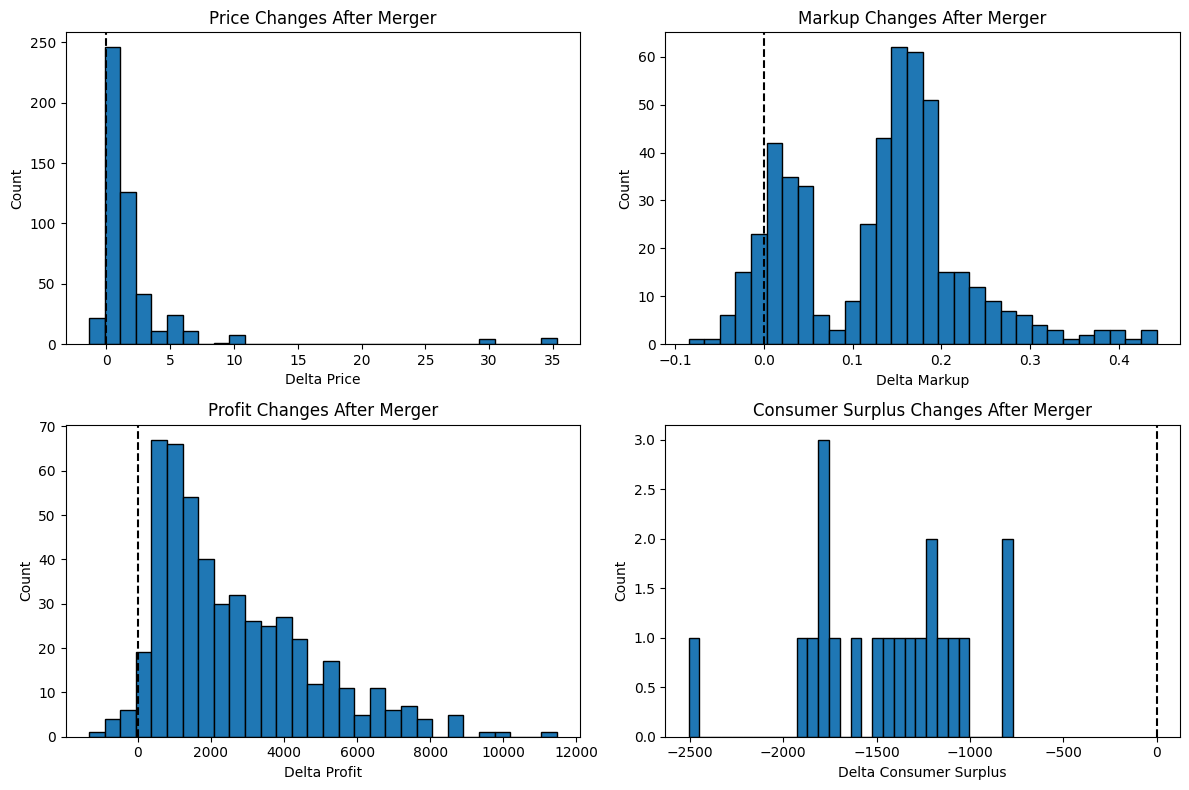

In [26]:
# Display the main product-level and market-level outputs together with descriptive summaries of the changes.
display(q5_product_table.head(10))
display(q5_market_table.head(10))
display(q5_product_table[['delta_price', 'delta_share', 'delta_markup', 'delta_profit']].describe())
display(q5_market_table[['delta_hhi', 'delta_cs']].describe())

# Plot the distributions of merger-induced changes in prices, markups, profits, and consumer surplus.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (q5_product_table['delta_price'], 'Price Changes After Merger', 'Delta Price'),
    (q5_product_table['delta_markup'], 'Markup Changes After Merger', 'Delta Markup'),
    (q5_product_table['delta_profit'], 'Profit Changes After Merger', 'Delta Profit'),
    (q5_market_table['delta_cs'], 'Consumer Surplus Changes After Merger', 'Delta Consumer Surplus'),
]
for ax, (series, title, xlabel) in zip(axes.flatten(), plots):
    ax.hist(series, bins=30, edgecolor='black')
    ax.axvline(0, linestyle='--', color='black')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Interpretation

After the merger, prices increase on average and market shares fall on average for individual products. The average change in HHI is about 2,038 points across markets, which is a very large increase in concentration.

Markups increase on average by about 0.129 across products. This makes sense because once firms 0, 1, 2, and 3 act as one owner, they internalize competition across their products and have a stronger incentive to raise prices.

Profits increase on average by about 2,608 dollars per product. The increase in profits is driven by the higher post-merger prices and markups, even though some products lose market share.

Consumer surplus decreases in every market. The average change is about -1,457 dollars per market when total population is fixed at 100,000 consumers across all markets. This happens because the merger raises concentration and prices, which makes consumers worse off on average.


# Question 6 Delivery Ceiling

- we return to the original 6-firm market structure (question 2)
- cap delivery time at 33 minutes (33/60 hours),
- hold estimated unobserved demand shocks $\xi$ and cost shocks $\omega$ fixed,
- initialize a pyblp.Simulation, and
- solve for the new endogenous equilibrium with replace_endogenous().

In [27]:
# Start from the same cleaned data and formulations used in Question 2.
q6_products = product_data.copy()
q6_agents = agent_data.copy()
q6_products['deliverytime_binding'] = (q6_products['deliverytime'] > 33 / 60).astype(int)
q6_products['deliverytime'] = q6_products['deliverytime'].clip(upper=33 / 60)

# Hold estimated unobservables fixed, following Week 10.
xi = results.xi
omega = results.omega

q6_simulation = pyblp.Simulation(
    product_formulations=product_formulations,
    beta=results.beta,
    sigma=results.sigma,
    gamma=results.gamma,
    product_data=q6_products.drop(columns=["deliverytime_binding"]),
    agent_data=q6_agents,
    agent_formulation=agent_formulation,
    pi=results.pi,
    xi=xi,
    omega=omega,
    seed=1,
)

# Replace simulated prices and market shares with equilibrium values consistent with the counterfactual.
q6_simulation_results = q6_simulation.replace_endogenous()
q6_simulation_results

Simulation Results Summary:
Computation  Fixed Point  Fixed Point  Contraction  Profit Gradients  Profit Hessians  Profit Hessians
   Time       Failures    Iterations   Evaluations      Max Norm      Min Eigenvalue   Max Eigenvalue 
-----------  -----------  -----------  -----------  ----------------  ---------------  ---------------
 00:00:00         0          1519         1519          +8.4E-13         -9.1E-02         -1.3E-05    

### 6.1. New equilibrium prices and market shares

,v1,market_ids,firm_ids,baseline_price,baseline_share,new_price,new_share,delta_price,delta_share
0,0,0,0,4.586001,0.006038,4.345851,0.006464,-0.240150,0.000427
1,1,0,0,4.171702,0.008047,4.203285,0.008189,0.031583,0.000142
2,2,0,0,4.966030,0.004980,4.674701,0.005363,-0.291328,0.000383
3,3,0,0,4.120471,0.006846,3.942988,0.007251,-0.177483,0.000405
4,4,0,0,3.267534,0.011540,3.179773,0.011991,-0.087761,0.000451
5,5,0,1,0.968238,0.060462,0.956670,0.062860,-0.011569,0.002398
6,6,0,1,4.306469,0.007761,4.177930,0.007941,-0.128539,0.000180
7,7,0,1,1.987181,0.050265,2.434576,0.042405,0.447395,-0.007860
8,8,0,1,4.546549,0.003045,4.402953,0.003114,-0.143596,0.000069
9,9,0,2,4.438455,0.007630,4.832485,0.007242,0.394030,-0.000388


,delta_price
count,500.000000
mean,0.080929
std,0.428287
min,-1.762756
25%,-0.074958
50%,-0.014041
75%,0.193194
max,5.702439


,delta_share
count,500.000000
mean,-0.000419
std,0.001951
min,-0.015580
25%,-0.000229
50%,0.000067
75%,0.000289
max,0.003595


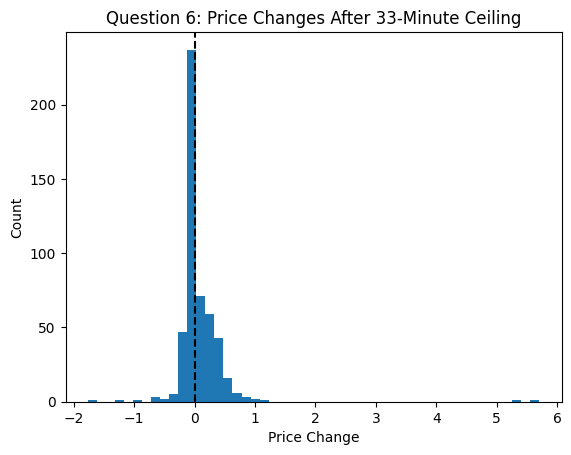

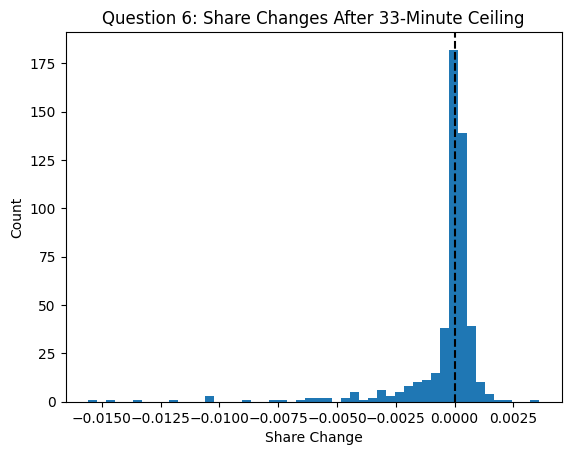

In [28]:
# Convert solved simulation into product data, following Week 10.
q6_problem = q6_simulation_results.to_problem()
q6_product_data_new = q6_problem.products
q6_df = pd.DataFrame(pyblp.data_to_dict(q6_product_data_new))

q6_equilibrium = product_data[['v1', 'market_ids', 'firm_ids', 'prices', 'shares']].copy()
q6_equilibrium = q6_equilibrium.rename(columns={'prices': 'baseline_price', 'shares': 'baseline_share'})
q6_equilibrium['new_price'] = q6_df['prices'].to_numpy()
q6_equilibrium['new_share'] = q6_df['shares'].to_numpy()
q6_equilibrium['delta_price'] = q6_equilibrium['new_price'] - q6_equilibrium['baseline_price']
q6_equilibrium['delta_share'] = q6_equilibrium['new_share'] - q6_equilibrium['baseline_share']

price_change = q6_df["prices"] - product_data["prices"]
share_change = q6_df["shares"] - product_data["shares"]

display(q6_equilibrium.head(10))
display(pd.Series(price_change).describe().to_frame("delta_price"))
display(pd.Series(share_change).describe().to_frame("delta_share"))

plt.hist(price_change, bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Question 6: Price Changes After 33-Minute Ceiling")
plt.xlabel("Price Change")
plt.ylabel("Count")
plt.show()

plt.hist(share_change, bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Question 6: Share Changes After 33-Minute Ceiling")
plt.xlabel("Share Change")
plt.ylabel("Count")
plt.show()

### 6.2. New marginal costs

,delta_mc
count,5.000000e+02
mean,6.917854e-02
std,9.278372e-02
min,-5.305054e-10
25%,-3.882950e-12
50%,3.311424e-10
75%,1.308034e-01
max,2.992113e-01


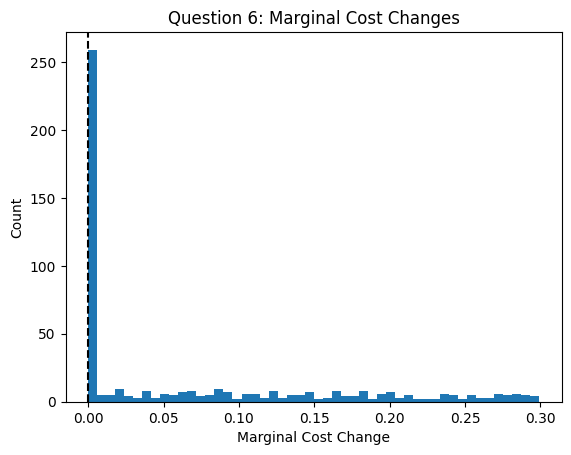

In [29]:
mc_q6 = q6_simulation_results.compute_costs().flatten()
mc_orig = results.compute_costs().flatten()
mc_change = mc_q6 - mc_orig

display(pd.Series(mc_change).describe().to_frame("delta_mc"))
plt.hist(mc_change, bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Question 6: Marginal Cost Changes")
plt.xlabel("Marginal Cost Change")
plt.ylabel("Count")
plt.show()


### 6.3. New markups

,delta_markup
count,500.000000
mean,-0.009958
std,0.019265
min,-0.141346
25%,-0.013546
50%,-0.009433
75%,-0.004538
max,0.216549


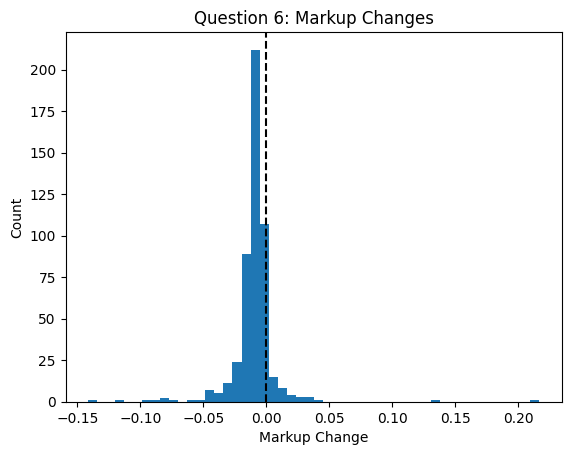

In [30]:
markups_q6 = q6_simulation_results.compute_markups(costs=mc_q6).flatten()
markups_orig = results.compute_markups(costs=mc_orig).flatten()
markup_change = markups_q6 - markups_orig

display(pd.Series(markup_change).describe().to_frame("delta_markup"))
plt.hist(markup_change, bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Question 6: Markup Changes")
plt.xlabel("Markup Change")
plt.ylabel("Count")
plt.show()

### 6.4. Consumer surplus

,market_ids,baseline_consumer_surplus,new_consumer_surplus,delta_consumer_surplus
0,0,16080.389550,16300.644242,220.254692
1,1,22013.496896,22122.108142,108.611246
2,2,16301.487999,16453.975729,152.487730
3,3,19814.244550,20028.080203,213.835653
4,4,21668.800799,22023.849396,355.048597
5,5,25058.239120,25370.223151,311.984030
6,6,17304.326631,17552.933179,248.606547
7,7,21138.102855,21545.446653,407.343797
8,8,18188.094517,18425.445052,237.350535
9,9,16944.826311,17208.696799,263.870488


,delta_consumer_surplus
count,20.000000
mean,276.766334
std,109.715731
min,96.256242
25%,211.696391
50%,266.943680
75%,336.536525
max,475.070283


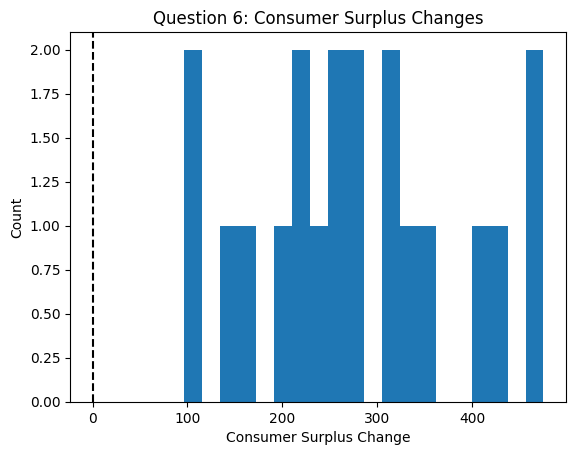

In [31]:
market_population = 100000 / product_data['market_ids'].nunique()
cs_q6 = q6_simulation_results.compute_consumer_surpluses().flatten() * market_population
cs_orig = results.compute_consumer_surpluses().flatten() * market_population
cs_change = cs_q6 - cs_orig

q6_cs_table = pd.DataFrame({
    'market_ids': np.sort(product_data['market_ids'].unique()),
    'baseline_consumer_surplus': cs_orig,
    'new_consumer_surplus': cs_q6,
    'delta_consumer_surplus': cs_change,
})

display(q6_cs_table)
display(pd.Series(cs_change).describe().to_frame("delta_consumer_surplus"))
plt.hist(cs_change, bins=20)
plt.axvline(0, linestyle="--", color="black")
plt.title("Question 6: Consumer Surplus Changes")
plt.xlabel("Consumer Surplus Change")
plt.ylabel("Count")
plt.show()


### Interpretation

The simulation converged with 0 fixed-point failures, so we were able to solve for the new equilibrium after imposing the 33-minute delivery ceiling and holding $\xi$ and $\omega$ fixed.

Prices move in both directions across products, but the average price change is positive. The mean change in price is about 0.08 dollars per slice, while the median is slightly negative at about -0.01 dollars. That suggests some products raise prices quite a bit after the cap, while many others change very little or even get slightly cheaper. A simple way to think about it is that the cap makes some pizzas more attractive to consumers, which pushes prices up, but it also raises marginal cost for the products whose delivery times are forced down, so the total price effect differs across products. Market-share changes are small on average, with a mean change of about -0.0004, but there is still variation across products.

Marginal costs increase on average. The mean change in marginal cost is about 0.07 dollars per slice, while the median is essentially 0. This fits the idea that the ceiling mainly matters for products that were originally above 33 minutes, since those are the products whose costs need to adjust.

Markups fall slightly on average. The mean change in markup is about -0.01 dollars per slice, and the median is about -0.009 dollars. So even though some firms benefit on the demand side from faster delivery, the cost increase is a bit stronger on average, which leads markups to fall slightly overall.

Consumer surplus increases in every market. Since the assignment asks us to assume there are 100,000 consumers in total, consumer surplus is scaled by 5,000 consumers per market across the 20 markets. Under that scaling, the mean increase in consumer surplus is about 277 dollars per market, with the smallest increase around 96 dollars and the largest around 475 dollars. This suggests that consumers value the shorter delivery times enough that overall welfare rises in every market under the counterfactual.


# Question 7 - Gentrification counterfactual

First we simulate the change in the agent distribution by changing the weights. For all rows where `invincome < 0.2`, we multiply the weights by 5 and do not redraw the population. Then we renormalize the weights within each market so that they sum to 1.

Holding the estimates from the original model fixed, we then simulate the new equilibrium and calculate the new prices, market shares, marginal costs, and markups.


In [32]:
agent_data.head()

,v1,market_ids,nodes0,nodes1,weights,invincome
0,0,0,0.052184,-0.127630,0.001,0.693219
1,1,0,-2.037323,-1.195798,0.001,0.177587
2,2,0,0.741513,0.443902,0.001,0.200069
3,3,0,-0.610369,-0.417627,0.001,0.664243
4,4,0,0.374030,-2.591600,0.001,0.307349


In [33]:
# Count how many rows have invincome < 0.2
count = (agent_data['invincome'] < 0.2).sum()
print(f"Number of agents with invincome < 0.2: {count}")

# number of rows in the agent data frame
len(agent_data)

Number of agents with invincome < 0.2: 3932


20000

In [34]:
# Impose change in agent data
# copy data set
agent_gen = agent_data.copy()

# Increase weights on high income individuals
high_income = agent_gen['invincome'] < 0.2
agent_gen.loc[high_income, 'weights'] *= 5

# Renormalize weights
agent_gen['weights'] = (
    agent_gen['weights'] /
    agent_gen.groupby('market_ids')['weights'].transform('sum')
)

In [35]:
# Keep residuals from earlier model
xi = results.xi
omega = results.omega

In [36]:
simulation = pyblp.Simulation(
    product_formulations = (
   pyblp.Formulation('0 + prices + deliverytime + rating'),
   pyblp.Formulation('1 + prices'),
   pyblp.Formulation('1 + rating + hourlywages + deliverytime')
),
        beta=results.beta,
        sigma=results.sigma,
        gamma=results.gamma,
        product_data=product_data,
        agent_data=agent_gen,
        agent_formulation=pyblp.Formulation('0 + invincome'),
        pi=results.pi,
        xi=xi,
        omega=omega,
        seed=1,
    )

simulation


Dimensions:
 T    N    F     I     K1    K2    K3    D 
---  ---  ---  -----  ----  ----  ----  ---
20   500   6   20000   3     2     4     1 

Formulations:
        Column Indices:              0           1             2            3      
-------------------------------  ---------  ------------  -----------  ------------
  X1: Linear Characteristics      prices    deliverytime    rating                 
 X2: Nonlinear Characteristics       1         prices                              
X3: Linear Cost Characteristics      1         rating     hourlywages  deliverytime
        d: Demographics          invincome                                         

Nonlinear Coefficient True Values:
Sigma:     1       prices   |   Pi:    invincome
------  --------  --------  |  ------  ---------
  1     +1.3E-01            |    1     +0.0E+00 
prices  +0.0E+00  +0.0E+00  |  prices  -4.1E+00 

Beta True Values:
 prices   deliverytime   rating 
--------  ------------  --------
-1.1E-02    -8.1E-01

In [37]:
# Replace simulated prices and market shares with equilibrium values that are consistent with true parameters.
simulation_results = simulation.replace_endogenous()
simulation_results
agent_data=simulation.agent_data

df= pd.DataFrame(pyblp.data_to_dict(agent_data))

In [38]:
# Convert solved simulation into a problem
problem = simulation_results.to_problem()

product_data_new=problem.products

df = pd.DataFrame(pyblp.data_to_dict(product_data_new))

### 7.1. Prices and Market Shares


In [39]:
# Build a product-level table comparing baseline and gentrification outcomes.
q7_equilibrium = product_data[['v1', 'market_ids', 'firm_ids', 'prices', 'shares']].copy()
q7_equilibrium = q7_equilibrium.rename(columns={'prices': 'baseline_price', 'shares': 'baseline_share'})
q7_equilibrium['new_price'] = df['prices'].to_numpy()
q7_equilibrium['new_share'] = df['shares'].to_numpy()
q7_equilibrium['delta_price'] = q7_equilibrium['new_price'] - q7_equilibrium['baseline_price']
q7_equilibrium['delta_share'] = q7_equilibrium['new_share'] - q7_equilibrium['baseline_share']

display(q7_equilibrium.head(10))


,v1,market_ids,firm_ids,baseline_price,baseline_share,new_price,new_share,delta_price,delta_share
0,0,0,0,4.586001,0.006038,5.528840,0.015255,0.942839,0.009217
1,1,0,0,4.171702,0.008047,5.295437,0.018054,1.123736,0.010006
2,2,0,0,4.966030,0.004980,5.718871,0.013875,0.752841,0.008895
3,3,0,0,4.120471,0.006846,5.264095,0.015120,1.143625,0.008275
4,4,0,0,3.267534,0.011540,4.638194,0.019056,1.370660,0.007516
5,5,0,1,0.968238,0.060462,1.592461,0.037837,0.624223,-0.022625
6,6,0,1,4.306469,0.007761,5.297997,0.018618,0.991527,0.010856
7,7,0,1,1.987181,0.050265,3.172252,0.048800,1.185071,-0.001465
8,8,0,1,4.546549,0.003045,5.443337,0.007780,0.896788,0.004735
9,9,0,2,4.438455,0.007630,5.388657,0.018897,0.950203,0.011267


#### Prices

,new_price
count,500.000000
mean,4.391889
std,1.089332
min,1.213414
25%,3.695022
50%,4.441666
75%,5.160518
max,6.880629


,delta_price
count,500.000000
mean,0.892552
std,0.293310
min,-0.634514
25%,0.786577
50%,0.949524
75%,1.062549
max,1.518653


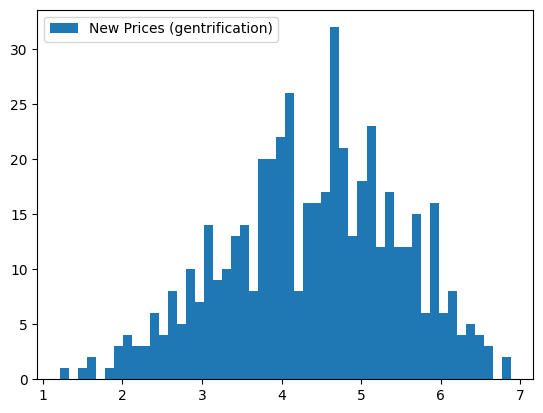

In [40]:
# Summarize new prices and price changes across products.
display(pd.Series(df['prices']).describe().to_frame('new_price'))
price_change = df['prices'] - product_data['prices']
display(pd.Series(price_change).describe().to_frame('delta_price'))

plt.hist(df['prices'], bins=50)
plt.legend(["New Prices (gentrification)"])
plt.show()


Text(0, 0.5, 'Count')

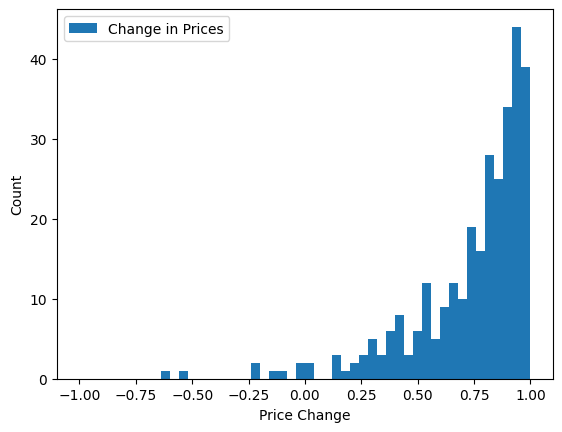

In [41]:
# Plot the distribution of price changes.
price_change = df['prices'] - product_data['prices']

plt.hist(price_change, bins=50, range=[-1,1])
plt.legend(["Change in Prices"])
plt.xlabel("Price Change")
plt.ylabel("Count")


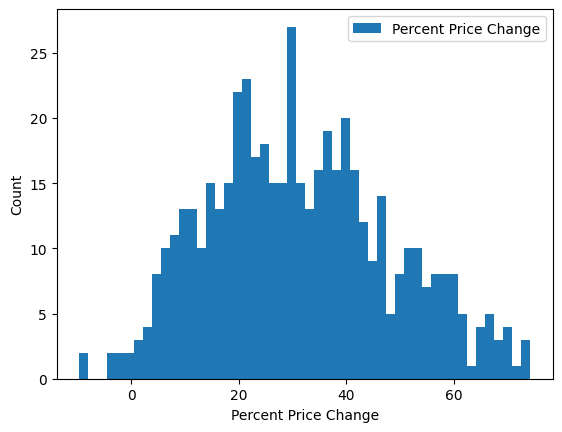

In [42]:
# Percent changes in prices
price_pct_change = 100 * (df['prices'] / product_data['prices'] - 1)

plt.hist(price_pct_change, bins=50)
plt.xlabel("Percent Price Change")
plt.ylabel("Count")
plt.legend(["Percent Price Change"])

#### Market Shares

,new_share
count,500.000000
mean,0.021710
std,0.009545
min,0.004154
25%,0.014674
50%,0.020090
75%,0.026745
max,0.056210


,delta_share
count,500.000000
mean,0.006519
std,0.007701
min,-0.024705
25%,0.003590
50%,0.007243
75%,0.010856
max,0.028582


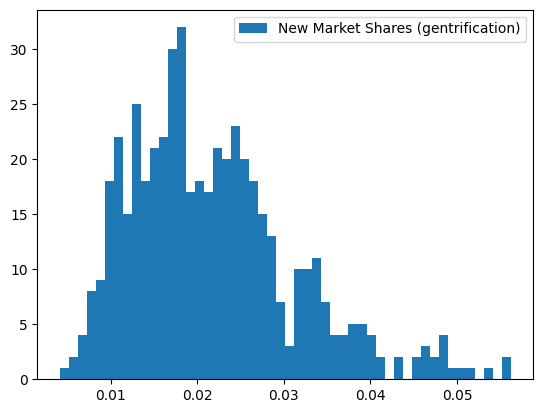

In [43]:
# Summarize new market shares and share changes across products.
display(pd.Series(df['shares']).describe().to_frame('new_share'))
share_change = df['shares'] - product_data['shares']
display(pd.Series(share_change).describe().to_frame('delta_share'))

plt.hist(df['shares'], bins=50)
plt.legend(["New Market Shares (gentrification)"])
plt.show()


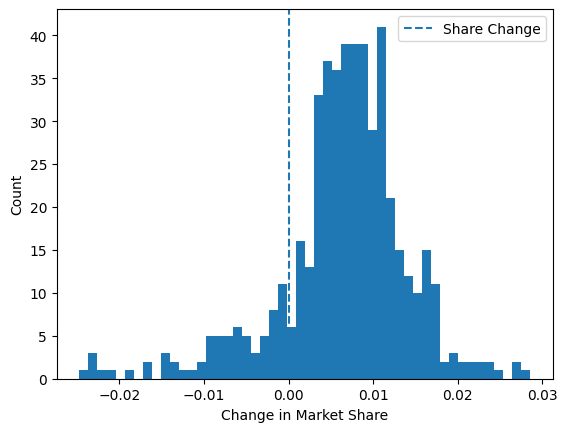

In [44]:
# Plot the distribution of share changes.
share_change = df['shares'] - product_data['shares']

plt.hist(share_change, bins=50)
plt.axvline(0, linestyle='--')
plt.xlabel("Change in Market Share")
plt.ylabel("Count")
plt.legend(["Share Change"])


Text(0, 0.5, 'Count')

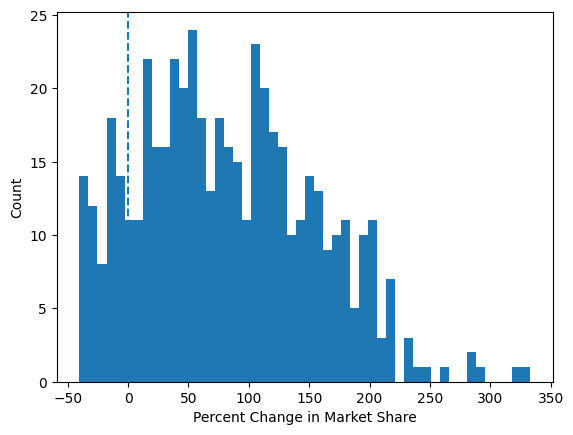

In [45]:
# Percent changes in market share
share_pct_change = 100 * (df['shares'] / product_data['shares'] - 1)

plt.hist(share_pct_change, bins=50)
plt.axvline(0, linestyle='--')
plt.xlabel("Percent Change in Market Share")
plt.ylabel("Count")

Text(0, 0.5, 'Counterfactual Market Share')

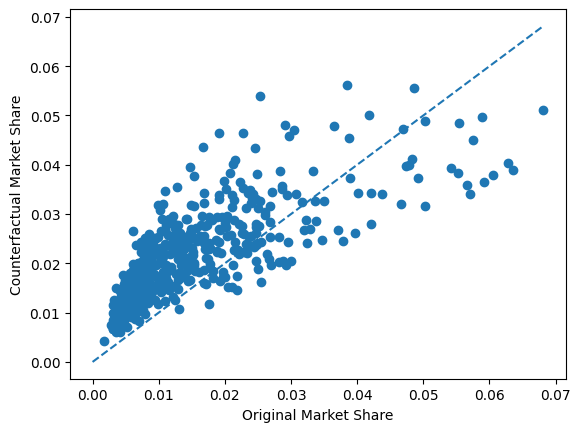

In [46]:
# As a scatter plot
plt.scatter(product_data['shares'], df['shares'])
plt.plot([0, max(product_data['shares'])],
         [0, max(product_data['shares'])],
         linestyle='--')

plt.xlabel("Original Market Share")
plt.ylabel("Counterfactual Market Share")

### Interpretation

The gentrification counterfactual raises prices on average. The average price increase is about 0.893 dollars per slice, with most products showing positive price changes. This fits the idea that a larger share of higher-income consumers makes demand less price sensitive on average, so firms can profitably charge higher prices.

Market shares also increase on average, by about 0.0065, but the distribution is mixed across products. Some pizzas gain a lot of share while others lose share, which makes sense because the change in the income distribution affects substitution patterns across products rather than shifting every product in exactly the same way.


#### Marginal costs

,new_marginal_cost
count,500.000000
mean,1.823218
std,0.578773
min,0.230516
25%,1.429346
50%,1.845768
75%,2.246162
max,3.166607


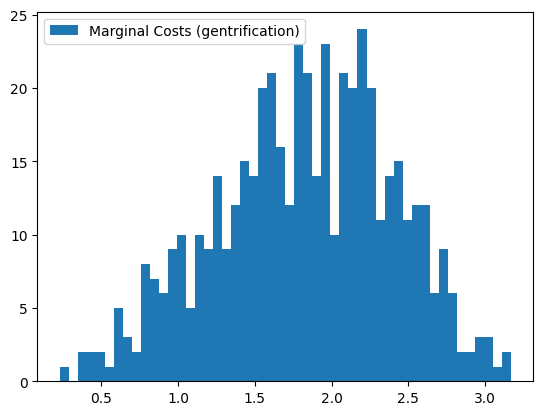

In [47]:
# Summarize new marginal costs and their changes.
mc_gen = simulation_results.compute_costs().flatten()
display(pd.Series(mc_gen).describe().to_frame('new_marginal_cost'))

plt.hist(mc_gen, bins=50)
plt.legend(["Marginal Costs (gentrification)"])
plt.show()


,delta_marginal_cost
count,5.000000e+02
mean,2.140064e-12
std,1.706366e-11
min,-7.787682e-11
25%,-1.318279e-12
50%,8.223422e-13
75%,2.547740e-12
max,1.645115e-10


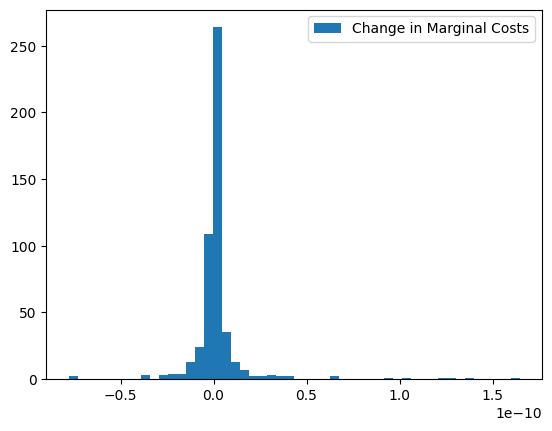

In [48]:
# Summarize and plot marginal-cost changes.
mc_orig = results.compute_costs().flatten()
mc_change = mc_gen - mc_orig
display(pd.Series(mc_change).describe().to_frame('delta_marginal_cost'))

plt.hist(mc_change, bins=50)
plt.legend(["Change in Marginal Costs"])


### Interpretation

Marginal costs are essentially unchanged in this counterfactual. The average change in marginal cost is effectively 0, which makes sense because the exercise changes the composition of consumers on the demand side, not the underlying cost shifters on the supply side.


#### Markups

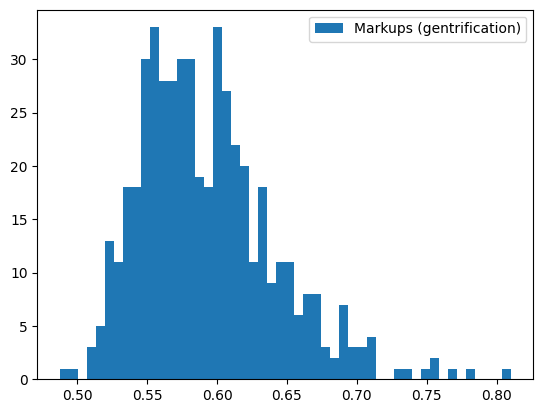

In [49]:
# Construct new markups
markups_gen = simulation_results.compute_markups(costs=mc_gen).flatten()
plt.hist(markups_gen, bins=50);
plt.legend(["Markups (gentrification)"]);

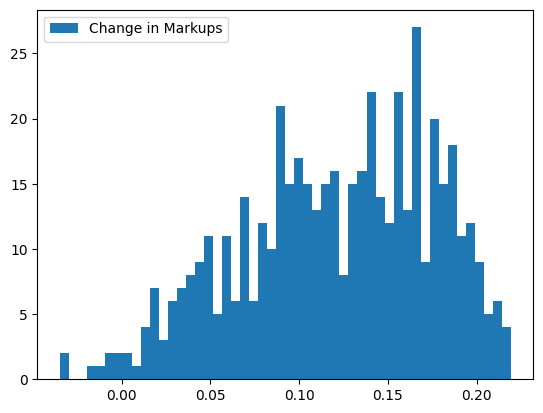

In [50]:
# Changes in markups
# Construct new markups
markups_gen = simulation_results.compute_markups(costs=mc_gen).flatten()

# Original markups
markups_orig = results.compute_markups(costs=mc_orig).flatten()

# Change in markups
mu_change = markups_gen - markups_orig

plt.hist(mu_change, bins=50);
plt.legend(["Change in Markups"]);

In [51]:
pd.Series(mu_change).describe()

count    500.000000
mean       0.121163
std        0.054123
min       -0.034724
25%        0.084702
50%        0.127515
75%        0.165031
max        0.219198
dtype: float64

### Interpretation

Markups increase in this counterfactual. The average markup increase is about 0.121 across products. Since prices rise while marginal costs stay close to their original levels, most of the increase in price shows up as higher markups rather than higher production costs.
